# End-to-End GFQL Benchmark: Dataframes, Search, Analytics, No Database

This notebook tells the benchmark story from a general-reader point of view.

The claim is not just that one GPU graph primitive is faster. The claim is that you can run an entire graph workflow directly on your Python dataframes, without standing up an external graph database, and that the GPU path accelerates both the **columnar dataframe work** and the **graph analytics work**.

This notebook only reads saved DGX benchmark results. It does **not** rerun the benchmarks.

It compares the **same general workflow on CPU and GPU**, plus a Neo4j reference run, so the reader can see where the speedups come from across the whole graph lifecycle.


## What is GFQL?

**GFQL** is Graphistry's dataframe-native graph query language. Instead of sending graph queries to an external database, GFQL runs directly on your in-memory Python graph/dataframe objects.

In this benchmark, the same overall workflow runs on:

- **CPU**: `pandas + igraph`
- **GPU**: `cudf + cugraph`

That is why the comparison is interesting: we are not switching products between CPU and GPU. We are switching execution backends while keeping the workflow dataframe-native.


## What is being benchmarked?

This is an end-to-end graph pipeline, not a single algorithm microbenchmark:

1. **Data loading** from a cached SNAP edge list
2. **Data shaping** to compute node degree as reusable node metadata
3. **Graph search** with local Cypher `MATCH ... RETURN GRAPH`
4. **Graph analytics** with local Cypher `CALL graphistry.{igraph,cugraph}.pagerank.write()`
5. **Graph search again** with local Cypher `MATCH ... RETURN GRAPH`
6. **Downstream use** of the final graph for analysis or visualization

That means the benchmark covers dataframe-native wrangling, graph search, and graph analytics in one story.


## Benchmark environment

These results come from **saved DGX runs**, not from rerunning the benchmark in this notebook.

- Host: `dgx-spark`
- GPU: `GB10`
- NVIDIA driver: `580.126.09`
- Container/runtime: `graphistry/test-gpu:latest`
- Result artifacts: `plans/gfql-gpu-pagerank-benchmark/results/`

The point of this notebook is to explain the benchmark clearly, not to make the reader wait for large graph runs.


g1 = g.gfql(
    "MATCH (seed)-[reach]-(nbr) "
    "WHERE seed.degree >= $degree_cutoff "
    "RETURN GRAPH",
    params={"degree_cutoff": degree_cutoff},
    engine=engine,
)

g2 = g1.gfql(
    f"CALL graphistry.{backend}.pagerank.write()",
    engine=engine,
)

g3 = g2.gfql(
    "MATCH (core)-[halo]-(nbr) "
    "WHERE core.pagerank >= $pagerank_cutoff "
    "RETURN GRAPH",
    params={"pagerank_cutoff": pagerank_cutoff},
    engine=engine,
)


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from benchmarks.gfql.filter_pagerank import presentation as pres

pres.setup_matplotlib()
display(pres.pipeline_overview_df())


,Phase,What happens,Why it matters
0,Data loading,Read cached SNAP edge list into a dataframe,"Shows dataframe-native ingest cost, not just graph runtime"
1,Data shaping,Compute node degree and materialize seed flags,Benchmarks the dataframe wrangling before any traversal
2,Graph search,Run GFQL neighborhood expansion around interesting nodes,Measures query/search on top of columnar data
3,Graph analytics,Run PageRank with igraph/cugraph or Neo4j GDS,Shows backend graph algorithm acceleration
4,Downstream use,Keep the final enriched subgraph for visualization or follow-on analysis,No external DB required; it stays in Python dataframes/graph objects


## Exact 3-way comparison on Twitter

Twitter is the best exact apples-to-apples comparison because all three systems finish comfortably on the same general workload shape.


,system,family,seconds,vs_fastest_x
0,Graphistry GPU\n(cudf + cugraph),Graphistry GPU,0.3059,1.00
1,Graphistry CPU\n(pandas + igraph),Graphistry CPU,2.3205,7.59
2,Neo4j + GDS,Neo4j,13.5058,44.15


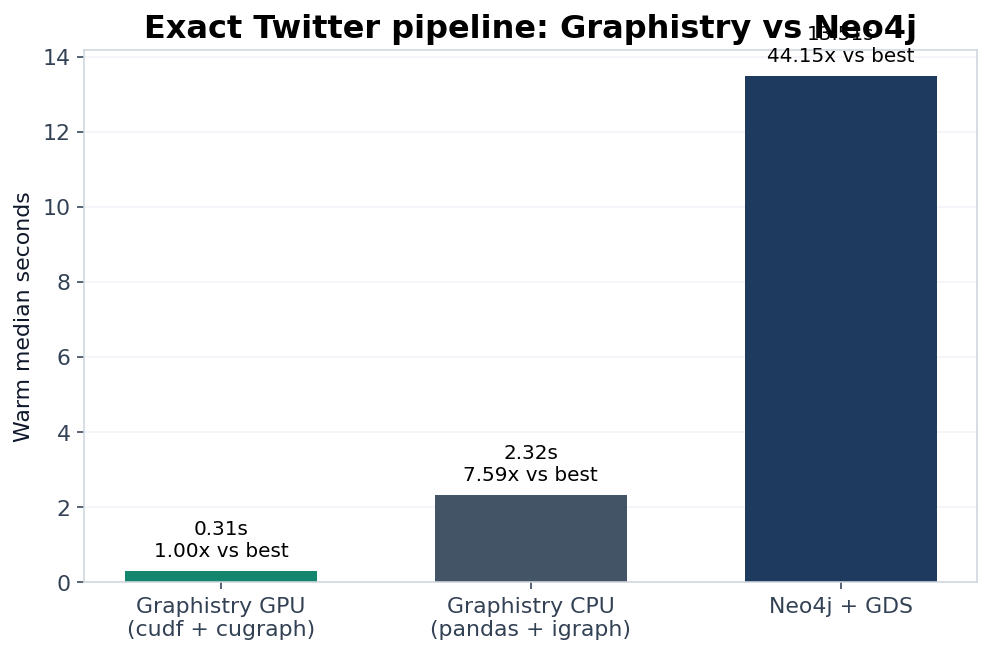

In [2]:
twitter_df = pres.twitter_three_way_df()
display(twitter_df)
pres.plot_twitter_three_way();


stage,PageRank,Search 1,Search 2
system,,,
Graphistry CPU\n(pandas + igraph),1.1878,0.7957,0.3414
Graphistry GPU\n(cudf + cugraph),0.0455,0.1503,0.1099
Neo4j + GDS,3.1974,5.7380,3.5096


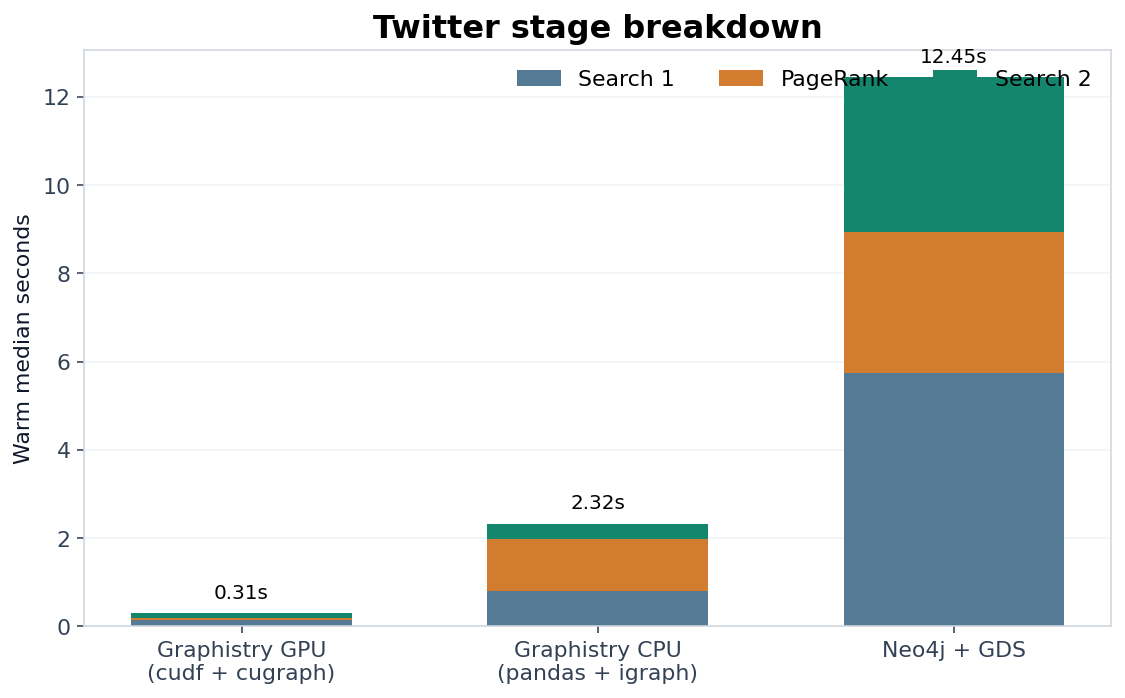

In [3]:
twitter_stage_df = pres.twitter_stage_df()
display(twitter_stage_df.pivot(index="system", columns="stage", values="seconds"))
pres.plot_twitter_stage_breakdown();


## Data loading and shaping are part of the benchmark

We also break out cached local file -> in-memory graph prep. This is important because the value proposition is not just graph kernels; it is the whole dataframe-native graph workflow.


stage                     Bind    Load  Shaping
dataset system                                 
GPlus   Graphistry CPU  0.0001  6.9096   1.8097
        Graphistry GPU  0.0001  3.0395   0.8613
Twitter Graphistry CPU  0.0001  0.2156   0.0620
        Graphistry GPU  0.0001  0.0862   0.0148

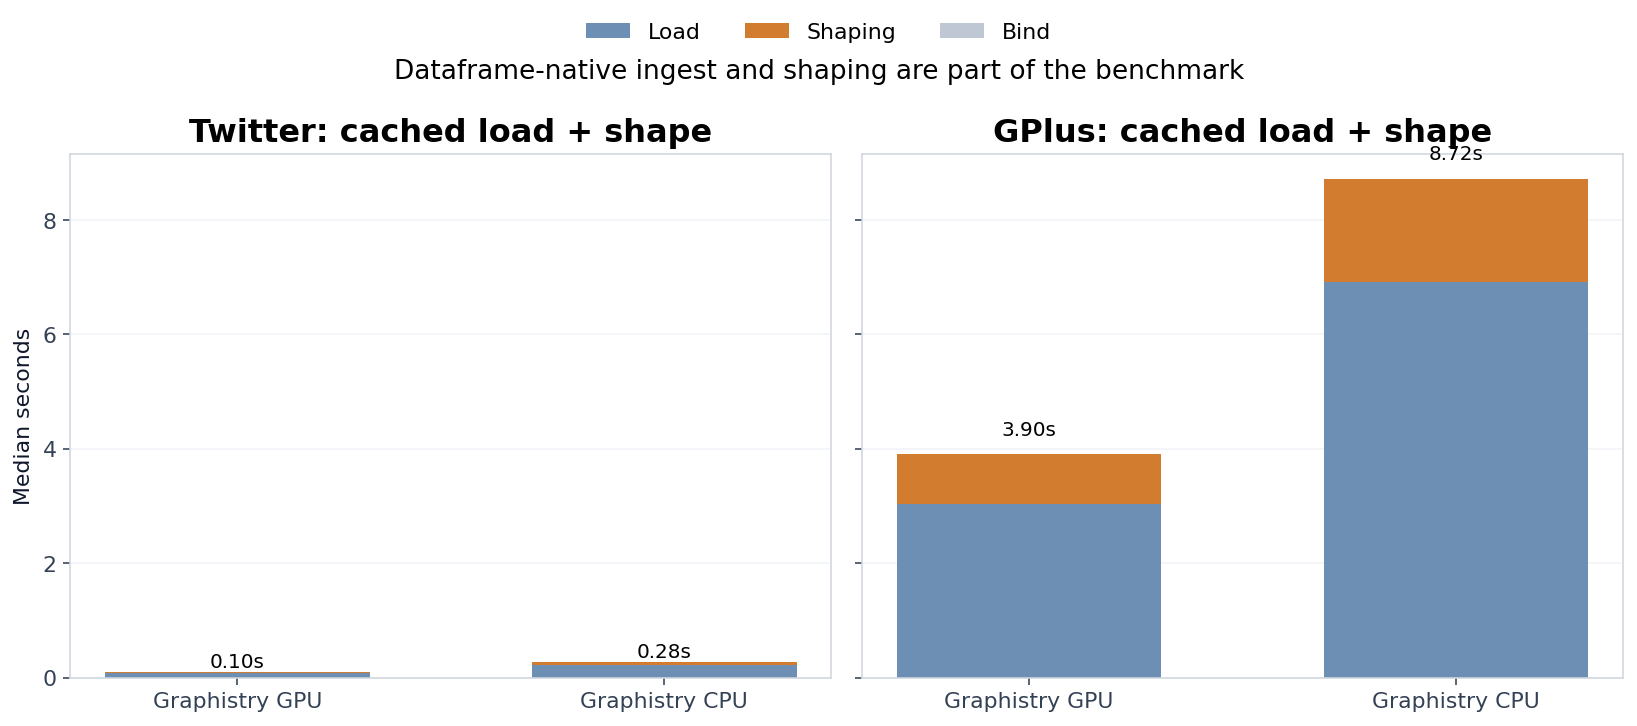

In [4]:
load_df = pres.load_breakdown_df()
display(load_df.pivot_table(index=["dataset", "system"], columns="stage", values="seconds"))
pres.plot_load_breakdown();


## Larger-graph story on GPlus

GPlus is where the CPU-vs-GPU difference becomes much more dramatic. It is also where Neo4j becomes expensive enough that the honest result is a lower bound instead of a polished exact number.


phase,Load + shape,Search + analytics pipeline
system,,
Graphistry CPU,9.4391,82.4775
Graphistry GPU,3.9712,4.0753


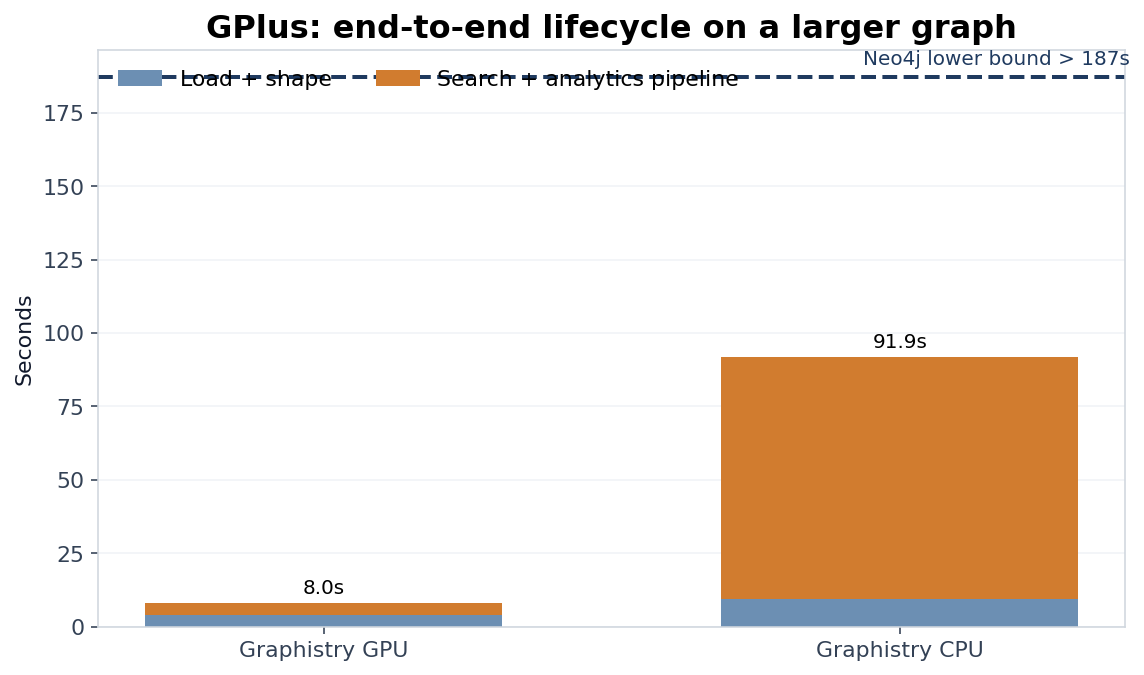

In [5]:
gplus_lifecycle_df = pres.gplus_lifecycle_df()
display(gplus_lifecycle_df.pivot(index="system", columns="phase", values="seconds"))
pres.plot_gplus_lifecycle();


## Why this matters

- **Free OSS**: the benchmark stays in open-source Python tooling.
- **No external DB required**: the Graphistry CPU and GPU paths run directly on your dataframes / graph objects.
- **CPU path is already useful**: even without the GPU, this shows a real graph pipeline that does not require a graph database.
- **GPU path compounds the win**: both the columnar dataframe work and the graph analytics work accelerate.

That is why this is more than “GPU PageRank is fast.” It is an end-to-end graph workflow running right where your data already is.


## Reproduction notes

The benchmark commands live under `benchmarks/gfql/filter_pagerank/`, but this notebook intentionally uses only saved result JSON files.

If you want to reproduce on DGX later, the current benchmark scripts are:

- `benchmarks/gfql/filter_pagerank/filter_pagerank_pipeline_cpu_gpu.py`
- `benchmarks/gfql/filter_pagerank/load_prepare_cpu_gpu.py`
- `benchmarks/gfql/filter_pagerank/filter_pagerank_pipeline_neo4j.py`
